In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
x = np.load('/content/data/X.npy')
y = np.load('/content/data/y.npy')

print(x.shape, y.shape)

(5000, 400) (5000, 1)


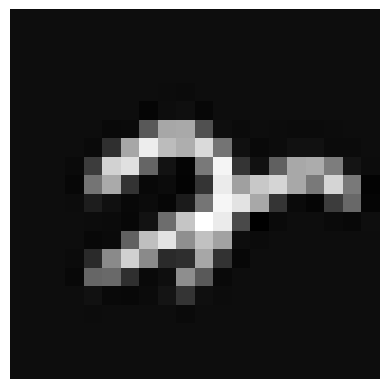

In [59]:
image = x[np.random.randint(x.shape[0])].reshape((20, 20))

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

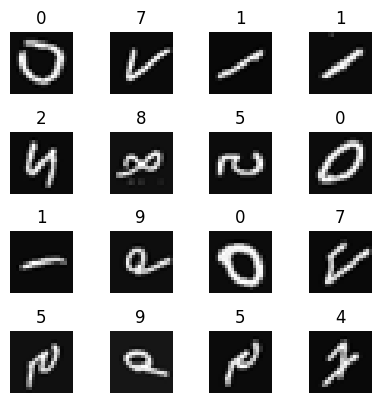

In [60]:
# pick randomly 16 samples
m, n = x.shape

fig, axes = plt.subplots(4, 4, figsize=(4, 4))
fig.tight_layout(pad = 0.1)

for i, ax in enumerate(axes.flat):
  idx = np.random.randint(m)
  image = x[idx].reshape((20, 20))

  ax.imshow(image, cmap='gray')

  ax.set_title(y[idx, 0])
  ax.axis('off')


In [61]:
x.shape

(5000, 400)

In [62]:
y.shape

(5000, 1)

In [63]:
def relu(z):
  return np.maximum(0, z)

In [64]:
def linear(z):
  return z

In [65]:
def softmax(z):
    # z: (N, C)
    z = z - np.max(z, axis=1, keepdims=True)   # numerical stability: mean scaling
    ex = np.exp(z)
    return ex / np.sum(ex, axis=1, keepdims=True)


In [ ]:
# to better understand the softmax functionality
out = np.array([[1,2,3],[2,4,6]])
print(out)

print(np.sum(out))

print(np.sum(out, axis=1))

In [66]:
def dense(a_in, w, b, g):
  z = np.dot(a_in, w.T) + b

  if g == 'relu':
    return relu(z)
  elif g == 'linear':
    return linear(z)
  else:
    return softmax(z)

In [67]:
def sequential (x, w1, b1, w2, b2, w3, b3, w4, b4):
  a1 = dense(x, w1, b1, 'relu')
  a2 = dense(a1, w2, b2, 'relu')
  a3 = dense(a2, w3, b3, 'linear')
  a4 = dense(a3, w4, b4, 'softmax')

  return a4

In [68]:
W1 = np.random.randn(10000).reshape((25, 400))
b1 = np.random.randn(25)

W2 = np.random.randn(375).reshape((15, 25))
b2 = np.random.randn(15)

W3 = np.random.randn(150).reshape((10, 15))
b3 = np.random.randn(10)

W4 = np.random.randn(100).reshape((10, 10))
b4 = np.random.randn(10)

print(W1.shape, W2.shape, W3.shape, W4.shape)
print(b1.shape, b2.shape, b3.shape, b4.shape)

(25, 400) (15, 25) (10, 15) (10, 10)
(25,) (15,) (10,) (10,)


In [69]:
a_out = sequential(x, W1, b1, W2, b2, W3, b3, W4, b4)
a_out.shape

(5000, 10)

In [70]:
yhat = np.argmax(a_out, axis=1)

In [71]:
accuracy = np.mean(yhat == y)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.1000
